In [46]:
import sys
print(sys.executable)
print(sys.version)

/Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/.venv/bin/python
3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]


In [68]:
# Import necessary libraries
%matplotlib inline

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.preprocessing import StandardScaler

In [48]:
# Download preprocessed dataset for feature engineering

CURRENT = Path.cwd()

if CURRENT.name == "notebooks":
    PROJECT_ROOT = CURRENT.parent
else:
    PROJECT_ROOT = CURRENT

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_DIR = OUTPUT_DIR / "model_configs"
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Data Directory:", DATA_DIR)
print("Output Directory:", OUTPUT_DIR)

Project Root: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab
Data Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data
Output Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs


In [49]:
# Load the preprocessed dataset

df = pd.read_parquet(DATA_DIR / "df_model_preprocessed.parquet")

print("\nDataset Loaded Successfully")
print("Shape:", df.shape)

df.head()


Dataset Loaded Successfully
Shape: (149390, 22)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,...,NumberOfDependents_median,DebtRatio_high_flag,DebtRatio_capped,DebtRatio_log,MonthlyIncome_missing_flag,MonthlyIncome_median,age_sq,RevolvingUtilization_high_flag,RevolvingUtilization_capped,RevolvingUtilization_log
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,...,2.0,0,0.802982,0.589442,0,9120.0,2025,0,0.766127,0.568789
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,...,1.0,0,0.121876,0.115002,0,2600.0,1600,0,0.957151,0.671490
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,...,0.0,0,0.085113,0.081684,0,3042.0,1444,0,0.658180,0.505721
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,...,0.0,0,0.036050,0.035415,0,3300.0,900,0,0.233810,0.210107
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,...,0.0,0,0.024926,0.024620,0,63588.0,2401,0,0.907239,0.645657


In [50]:
# Target variable check for finalization of feature engineering strategy

target = "SeriousDlqin2yrs"

print("Shape:", df.shape)
print("Target exists:", target in df.columns)

print("Target distribution:")
print(df[target].value_counts(dropna=False))

print("Target distribution (%):")
print((df[target].value_counts(normalize=True, dropna=False) * 100).round(2))

print("Missing values check:")
print(df.isna().sum().sort_values(ascending=False).head(20))

print("Infinite value check:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum().sort_values(ascending=False)
print(inf_counts[inf_counts > 0])

print("Duplicate rows:")
print(df.duplicated().sum())

Shape: (149390, 22)
Target exists: True
Target distribution:
SeriousDlqin2yrs
0    139381
1     10009
Name: count, dtype: int64
Target distribution (%):
SeriousDlqin2yrs
0    93.3
1     6.7
Name: proportion, dtype: float64
Missing values check:
MonthlyIncome                           29221
NumberOfDependents                       3828
SeriousDlqin2yrs                            0
NumberOfDependents_median                   0
RevolvingUtilization_capped                 0
RevolvingUtilization_high_flag              0
age_sq                                      0
MonthlyIncome_median                        0
MonthlyIncome_missing_flag                  0
DebtRatio_log                               0
DebtRatio_capped                            0
DebtRatio_high_flag                         0
NumberOfDependents_missing_flag             0
RevolvingUtilizationOfUnsecuredLines        0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberRealEstateLoansOrLines                0
NumberOfTimes90Days

In [51]:
# Features set for modeling (excluding target and ID columns)

# ==========================================================
# Step 4: Final Candidate Feature Inventory
# ==========================================================

target = "SeriousDlqin2yrs"

base_features = [
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents_median",
    "NumberOfDependents_missing_flag",
    "MonthlyIncome_median",
    "MonthlyIncome_missing_flag",
    "DebtRatio_log",
    "DebtRatio_high_flag",
    "RevolvingUtilization_log",
    "RevolvingUtilization_high_flag"
]

added_feature = [
    "age_sq"
]

all_features = base_features + added_feature

print("Base feature count:", len(base_features))
print("Added feature count:", len(added_feature))
print("Total candidate features:", len(all_features))

features_set = pd.DataFrame({
    "feature_name": all_features,
    "feature_group": (
        ["base"] * len(base_features) +
        ["engineered"] * len(added_feature)
    )
})

features_set

Base feature count: 14
Added feature count: 1
Total candidate features: 15


,feature_name,feature_group
0,age,base
1,NumberOfTime30-59DaysPastDueNotWorse,base
2,NumberOfTime60-89DaysPastDueNotWorse,base
3,NumberOfTimes90DaysLate,base
4,NumberOfOpenCreditLinesAndLoans,base
5,NumberRealEstateLoansOrLines,base
6,NumberOfDependents_median,base
7,NumberOfDependents_missing_flag,base
8,MonthlyIncome_median,base
9,MonthlyIncome_missing_flag,base


Model dataset shape: (149390, 16)

Missing values:
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfTimes90DaysLate                 0
NumberOfOpenCreditLinesAndLoans         0
NumberRealEstateLoansOrLines            0
NumberOfDependents_median               0
NumberOfDependents_missing_flag         0
MonthlyIncome_median                    0
MonthlyIncome_missing_flag              0
DebtRatio_log                           0
DebtRatio_high_flag                     0
RevolvingUtilization_log                0
RevolvingUtilization_high_flag          0
age_sq                                  0
dtype: int64

Lowest variance features:
                                 feature   variance
13        RevolvingUtilization_high_flag   0.002477
7        NumberOfDependents_missing_flag   0.024968
12              RevolvingUtilization_log   0.062822
11                   DebtRatio_high_flag   0.155919
9             Month

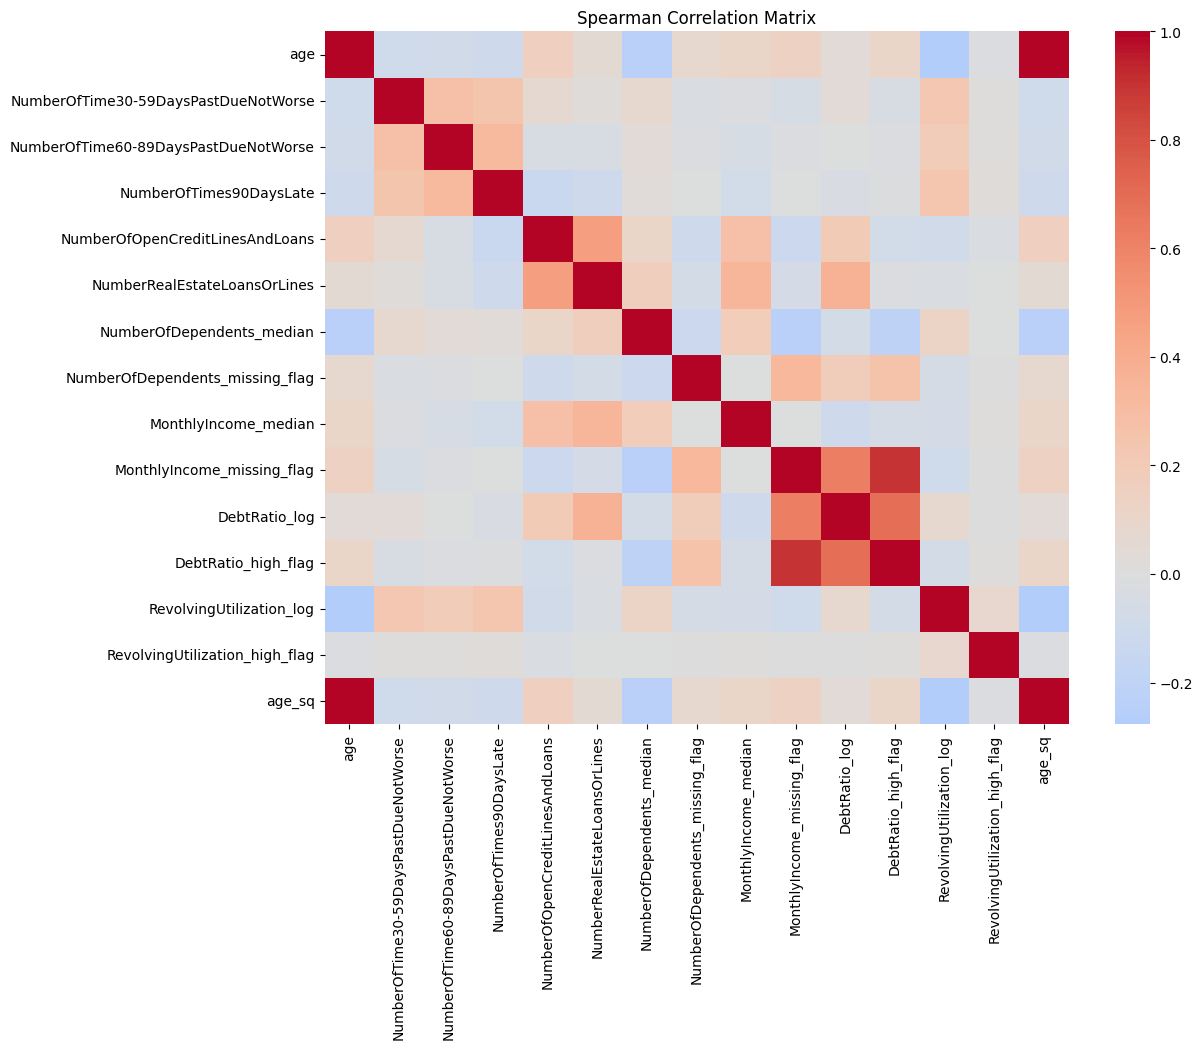


NumberOfDependents_missing_flag
                                 observations  bad_rate
NumberOfDependents_missing_flag                        
0                                      145562  0.067538
1                                        3828  0.046499

MonthlyIncome_missing_flag
                            observations  bad_rate
MonthlyIncome_missing_flag                        
0                                 120169  0.069527
1                                  29221  0.056603

DebtRatio_high_flag
                     observations  bad_rate
DebtRatio_high_flag                        
0                          120517  0.069708
1                           28873  0.055692

RevolvingUtilization_high_flag
                                observations  bad_rate
RevolvingUtilization_high_flag                        
0                                     149019  0.066804
1                                        371  0.145553


In [52]:
# Features diagnostics before creating datasets for modeling

# Shape

model_df = df[[target] + all_features].copy()
print("Model dataset shape:", model_df.shape)

# Missing values

print("\nMissing values:")
print(model_df[all_features].isna().sum().sort_values(ascending=False))

# Variables variance check for potential zero-variance features

variance_df = pd.DataFrame({
    "feature": all_features,
    "variance": model_df[all_features].var().values
}).sort_values("variance")

print("\nLowest variance features:")
print(variance_df.head(10))

# Correlation matrix for numeric features

corr_matrix = model_df[all_features].corr(method="spearman")

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix")
plt.show()

# Flag variables distribution and relationship with target

flag_cols = [
    "NumberOfDependents_missing_flag",
    "MonthlyIncome_missing_flag",
    "DebtRatio_high_flag",
    "RevolvingUtilization_high_flag"
]

for col in flag_cols:
    print(f"\n{col}")
    print(
        model_df.groupby(col)[target]
        .agg(observations="count", bad_rate="mean")
    )

In [53]:
# Start with building dataset for logistic regression. This includes binning features, which implies calculating WOE and IV for variables to justify binning.

# WOE and IV calculation function for binned features

def calculate_woe_iv(data, feature, target, bin_col):
    """
    Calculates WOE and IV for a pre-binned feature.
    Assumes:
    - target = 1 is bad/event
    - target = 0 is good/non-event
    """

    temp = data[[bin_col, target]].copy()

    grouped = (
        temp.groupby(bin_col, observed=False)[target]
        .agg(
            total="count",
            bad="sum"
        )
        .reset_index()
    )

    grouped["good"] = grouped["total"] - grouped["bad"]

    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()

    # smoothing to avoid divide-by-zero
    grouped["good_dist"] = (grouped["good"] + 0.5) / (total_good + 0.5 * len(grouped))
    grouped["bad_dist"] = (grouped["bad"] + 0.5) / (total_bad + 0.5 * len(grouped))

    grouped["bad_rate"] = grouped["bad"] / grouped["total"]

    grouped["woe"] = np.log(grouped["good_dist"] / grouped["bad_dist"])
    grouped["iv_bin"] = (grouped["good_dist"] - grouped["bad_dist"]) * grouped["woe"]

    grouped["feature"] = feature
    grouped["bin_col"] = bin_col

    iv_total = grouped["iv_bin"].sum()

    grouped["iv_total"] = iv_total

    return grouped


def create_decile_bins(data, feature, max_bins=10):
    """
    Creates decile bins for continuous variables.
    Duplicate edges are dropped automatically.
    """

    bin_col = feature + "_bin"

    data[bin_col] = pd.qcut(
        data[feature],
        q=max_bins,
        duplicates="drop"
    )

    return data, bin_col


def create_count_bins(data, feature):
    """
    Creates business-friendly bins for count variables.
    """

    bin_col = feature + "_bin"

    data[bin_col] = np.select(
        [
            data[feature] == 0,
            data[feature] == 1,
            data[feature] == 2,
            data[feature] >= 3
        ],
        [
            "0",
            "1",
            "2",
            "3+"
        ],
        default="unknown"
    )

    return data, bin_col


def create_binary_bins(data, feature):
    """
    Creates bins for binary indicator variables.
    """

    bin_col = feature + "_bin"

    data[bin_col] = data[feature].astype(int).astype(str)

    return data, bin_col


# Variable groups for WOE/IV calculation and binning strategy

target = "SeriousDlqin2yrs"

# Continuous variables: raw + transformed where relevant
woe_continuous_vars = [
    "age",
    "MonthlyIncome_median",
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines",
]

# Count variables: business-friendly bins
woe_count_vars = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents_median"
]

# Binary variables: 0/1 bins
woe_binary_vars = [
    "MonthlyIncome_missing_flag",
    "NumberOfDependents_missing_flag",
    "DebtRatio_high_flag",
    "RevolvingUtilization_high_flag"
]

woe_all_vars = (
    woe_continuous_vars
    + woe_count_vars
    + woe_binary_vars
)

# Create binned features and calculate WOE/IV tables for each variable group

woe_working_df = df.copy()

woe_tables = []
bin_columns = {}

# Continuous variables: decile bins

for feature in woe_continuous_vars:
    woe_working_df, bin_col = create_decile_bins(
        woe_working_df,
        feature,
        max_bins=10
    )
    
    bin_columns[feature] = bin_col
    
    woe_table = calculate_woe_iv(
        data=woe_working_df,
        feature=feature,
        target=target,
        bin_col=bin_col
    )
    
    woe_tables.append(woe_table)

# Count variables: business-friendly bins

for feature in woe_count_vars:
    woe_working_df, bin_col = create_count_bins(
        woe_working_df,
        feature
    )
    
    bin_columns[feature] = bin_col
    
    woe_table = calculate_woe_iv(
        data=woe_working_df,
        feature=feature,
        target=target,
        bin_col=bin_col
    )
    
    woe_tables.append(woe_table)

# Binary variables: 0/1 bins

for feature in woe_binary_vars:
    woe_working_df, bin_col = create_binary_bins(
        woe_working_df,
        feature
    )
    
    bin_columns[feature] = bin_col
    
    woe_table = calculate_woe_iv(
        data=woe_working_df,
        feature=feature,
        target=target,
        bin_col=bin_col
    )
    
    woe_tables.append(woe_table)

# Combine all WOE tables into a single DataFrame for analysis

woe_detail_df = pd.concat(woe_tables, ignore_index=True)

iv_summary_df = (
    woe_detail_df[["feature", "iv_total"]]
    .drop_duplicates()
    .sort_values("iv_total", ascending=False)
    .reset_index(drop=True)
)

print("WOE detail shape:", woe_detail_df.shape)
print("IV summary shape:", iv_summary_df.shape)

iv_summary_df

# WOE tables for all variables

for var in iv_summary_df["feature"]:

    print("\n" + "=" * 100)
    print(f"VARIABLE: {var}")
    print("=" * 100)

    display(
        woe_detail_df.loc[
            woe_detail_df["feature"] == var,
            [
                bin_columns[var],
                "total",
                "bad",
                "good",
                "bad_rate",
                "woe",
                "iv_bin"
            ]
        ].reset_index(drop=True)
    )

WOE detail shape: (72, 25)
IV summary shape: (14, 2)

VARIABLE: RevolvingUtilizationOfUnsecuredLines


,RevolvingUtilizationOfUnsecuredLines_bin,total,bad,good,bad_rate,woe,iv_bin
0,"(-0.001, 0.0032]",14939,383,14556,0.025638,1.003190,0.066348
1,"(0.0032, 0.0194]",14939,200,14739,0.013388,1.664209,0.142663
2,"(0.0194, 0.0437]",14939,210,14729,0.014057,1.614859,0.136704
3,"(0.0437, 0.0834]",14939,286,14653,0.019145,1.301433,0.099584
4,"(0.0834, 0.154]",14939,356,14583,0.023830,1.078049,0.074414
5,"(0.154, 0.271]",14939,521,14418,0.034875,0.686295,0.035252
6,"(0.271, 0.443]",14939,778,14161,0.052078,0.267650,0.006386
7,"(0.443, 0.695]",14939,1311,13628,0.087757,-0.292271,0.009701
8,"(0.695, 0.978]",14941,2452,12489,0.164112,-1.005483,0.156155
9,"(0.978, 50708.0]",14937,3512,11425,0.235121,-1.453743,0.390750



VARIABLE: NumberOfTimes90DaysLate


,NumberOfTimes90DaysLate_bin,total,bad,good,bad_rate,woe,iv_bin
0,0,141107,6549,134558,0.046412,0.389069,0.121061
1,1,5232,1764,3468,0.337156,-1.957686,0.296338
2,2,1555,776,779,0.499035,-2.629685,0.189264
3,3+,1496,920,576,0.614973,-3.101483,0.272350



VARIABLE: NumberOfTime30-59DaysPastDueNotWorse


...

,MonthlyIncome_missing_flag_bin,total,bad,good,bad_rate,woe,iv_bin
0,0,120169,8355,111814,0.069527,-0.039713,0.001291
1,1,29221,1654,27567,0.056603,0.179505,0.005834



VARIABLE: NumberOfDependents_missing_flag


,NumberOfDependents_missing_flag_bin,total,bad,good,bad_rate,woe,iv_bin
0,0,145562,9831,135731,0.067538,-0.008547,0.000071
1,1,3828,178,3650,0.046499,0.384397,0.003213



VARIABLE: RevolvingUtilization_high_flag


,RevolvingUtilization_high_flag_bin,total,bad,good,bad_rate,woe,iv_bin
0,0,149019,9955,139064,0.066804,0.003179,0.000010
1,1,371,54,317,0.145553,-0.871357,0.002759


In [54]:
# ==========================================================
# Custom Binning: Revolving Utilization of Unsecured Lines
#
# Why these bins were selected:
# 1. Replace arbitrary decile cutoffs with business-meaningful utilization bands.
# 2. Credit utilization is naturally interpreted as % of available revolving credit used.
# 3. Prior WOE review showed monotonic worsening risk as utilization increased.
# 4. Separate 75-100% from 100%+ to isolate maxed / over-limit / anomalous users.
# 5. Explicit zero-usage bucket retained because zero utilization often behaves differently.
# ==========================================================

util_var = "RevolvingUtilizationOfUnsecuredLines"

df["RevolvingUtilization_final_bin"] = pd.cut(
    df[util_var],
    bins=[-0.001, 0, 0.05, 0.15, 0.30, 0.50, 0.75, 1.00, np.inf],
    labels=[
        "=0",
        "0-5%",
        "5-15%",
        "15-30%",
        "30-50%",
        "50-75%",
        "75-100%",
        "100%+"
    ],
    right=True,
    include_lowest=True
)

# Generate WOE / IV table for final bins
util_woe_final = calculate_woe_iv(
    data=df,
    feature=util_var,
    target=target,
    bin_col="RevolvingUtilization_final_bin"
)

util_woe_final[
    [
        "RevolvingUtilization_final_bin",
        "total",
        "bad",
        "good",
        "bad_rate",
        "woe",
        "iv_bin"
    ]
]

,RevolvingUtilization_final_bin,total,bad,good,bad_rate,woe,iv_bin
0,=0,10569,320,10249,0.030277,0.831746,0.034539
1,0-5%,37201,530,36671,0.014247,1.602580,0.336724
2,5-15%,26243,572,25671,0.021796,1.169768,0.148562
3,15-30%,18560,639,17921,0.034429,0.699714,0.045277
4,30-50%,15830,926,14904,0.058497,0.144649,0.002083
5,50-75%,13764,1394,12370,0.101279,-0.450577,0.022762
6,75-100%,23902,4391,19511,0.183708,-1.142022,0.341005
7,100%+,3321,1237,2084,0.372478,-2.111920,0.229427


In [55]:
# ==========================================================
# Custom Binning: Age
#
# Why these bins were selected:
# 1. Replace narrow decile splits with interpretable life-stage bands.
# 2. Prior WOE review showed monotonic decline in risk with age.
# 3. Decade-style groupings are easy to explain to business users.
# 4. Broader bins improve stability and reduce overfitting.
# 5. 70+ retained separately because older borrowers showed distinctly lower risk.
# ==========================================================

age_var = "age"

df["age_final_bin"] = pd.cut(
    df[age_var],
    bins=[20, 29, 39, 49, 59, 69, np.inf],
    labels=[
        "21-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ],
    right=True,
    include_lowest=True
)

# Generate WOE / IV table for final bins
age_woe_final = calculate_woe_iv(
    data=df,
    feature=age_var,
    target=target,
    bin_col="age_final_bin"
)

age_woe_final[
    [
        "age_final_bin",
        "total",
        "bad",
        "good",
        "bad_rate",
        "woe",
        "iv_bin"
    ]
]

# ==========================================================
# Custom Binning: Age (Merged Younger Cohorts Version)
#
# Why these bins were selected:
# 1. Prior WOE review showed monotonic decline in default risk as age increased.
# 2. Borrowers under 40 exhibited consistently higher risk than older groups.
# 3. 21-29 and 30-39 were merged into a single 21-39 bucket because:
#    - both represent younger / working-age borrowers
#    - both showed elevated default rates relative to older cohorts
#    - merging improves sample size and bin stability
#    - simplifies scorecard interpretation with limited information loss
# 4. Older age bands were retained separately because risk continued to decline
#    materially with age.
# 5. Broader bins reduce overfitting and improve long-run governance stability.
# ==========================================================

age_var = "age"

df["age_final_bin_v2"] = pd.cut(
    df[age_var],
    bins=[20, 39, 49, 59, 69, np.inf],
    labels=[
        "21-39",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ],
    right=True,
    include_lowest=True
)

# Generate WOE / IV table
age_woe_final_v2 = calculate_woe_iv(
    data=df,
    feature=age_var,
    target=target,
    bin_col="age_final_bin_v2"
)

age_woe_final_v2[
    [
        "age_final_bin_v2",
        "total",
        "bad",
        "good",
        "bad_rate",
        "woe",
        "iv_bin"
    ]
]

,age_final_bin_v2,total,bad,good,bad_rate,woe,iv_bin
0,21-39,31747,3359,28388,0.105805,-0.499303,0.065854
1,40-49,34339,2876,31463,0.083753,-0.241241,0.014857
2,50-59,35231,2274,32957,0.064545,0.039964,0.000370
3,60-69,28816,1050,27766,0.036438,0.641069,0.060440
4,70+,19257,450,18807,0.023368,1.098158,0.098763


In [56]:
# ==========================================================
# Custom Binning: Number of Open Credit Lines and Loans
#
# Why these bins were selected:
# 1. Initial WOE review showed borrowers with 0, 1, or 2 open lines had
#    materially higher default risk than the broader population.
# 2. Thin-file customers often behave differently, so 0 / 1 / 2 were kept separate.
# 3. The prior "3+" bucket was too large and masked useful segmentation.
# 4. 3-5 and 6-9 represent moderate credit depth / established usage.
# 5. 10+ isolates highly active / mature borrowers, who may behave differently.
# 6. Broader grouped bins improve interpretability, stability, and scorecard usability.
# ==========================================================

open_lines_var = "NumberOfOpenCreditLinesAndLoans"

df["OpenCreditLines_final_bin"] = pd.cut(
    df[open_lines_var],
    bins=[-0.001, 0, 1, 2, 5, 9, np.inf],
    labels=[
        "0",
        "1",
        "2",
        "3-5",
        "6-9",
        "10+"
    ],
    right=True,
    include_lowest=True
)

# Generate WOE / IV table
open_lines_woe_final = calculate_woe_iv(
    data=df,
    feature=open_lines_var,
    target=target,
    bin_col="OpenCreditLines_final_bin"
)

open_lines_woe_final[
    [
        "OpenCreditLines_final_bin",
        "total",
        "bad",
        "good",
        "bad_rate",
        "woe",
        "iv_bin"
    ]
]

# ==========================================================
# Custom Binning: Number of Open Credit Lines and Loans - V2
#
# Why this revision was selected:
# 1. Prior custom bins showed risk declined from 0 to 6-9 open lines,
#    but increased again in the 10+ bucket.
# 2. This suggests a nonlinear / U-shaped relationship.
# 3. 10+ was therefore split into 10-14 and 15+ to isolate very high
#    credit-line activity.
# 4. 0 / 1 / 2 remain separate because thin-file borrowers showed
#    materially higher default risk.
# ==========================================================

open_lines_var = "NumberOfOpenCreditLinesAndLoans"

df["OpenCreditLines_final_bin_v2"] = pd.cut(
    df[open_lines_var],
    bins=[-0.001, 0, 1, 2, 5, 9, 14, np.inf],
    labels=[
        "0",
        "1",
        "2",
        "3-5",
        "6-9",
        "10-14",
        "15+"
    ],
    right=True,
    include_lowest=True
)

open_lines_woe_final_v2 = calculate_woe_iv(
    data=df,
    feature=open_lines_var,
    target=target,
    bin_col="OpenCreditLines_final_bin_v2"
)

open_lines_woe_final_v2[
    [
        "OpenCreditLines_final_bin_v2",
        "total",
        "bad",
        "good",
        "bad_rate",
        "woe",
        "iv_bin"
    ]
]

,OpenCreditLines_final_bin_v2,total,bad,good,bad_rate,woe,iv_bin
0,0,1712,468,1244,0.273364,-1.656449,6.271808e-02
1,1,4251,584,3667,0.137379,-0.796893,2.555232e-02
2,2,6558,609,5949,0.092864,-0.354978,6.456995e-03
3,3-5,33474,2244,31230,0.067037,-0.000490,5.371927e-08
4,6-9,50762,2771,47991,0.054588,0.218233,1.473209e-02
5,10-14,35162,2096,33066,0.059610,0.124849,3.476306e-03
6,15+,17471,1237,16234,0.070803,-0.059357,4.227808e-04


In [57]:
# ==========================================================
# Custom Binning: Monthly Income
#
# Why these bins were selected:
# 1. Automatic deciles were distorted by median imputation at 5400.
# 2. Income is more interpretable using economic earning bands.
# 3. Separate missing_flag already captures imputed / missing cases.
# 4. Higher income generally associated with lower default risk.
# 5. Broad bands improve stability and reduce overfitting.
# ==========================================================

income_var = "MonthlyIncome_median"

df["MonthlyIncome_final_bin"] = pd.cut(
    df[income_var],
    bins=[-0.001, 5000, 10000, np.inf],
    labels=[
        "0-5000",
        "5000-10000",
        "10000+",
    ],
    right=True,
    include_lowest=True
)

# Generate WOE / IV table
income_woe_final = calculate_woe_iv(
    data=df,
    feature=income_var,
    target=target,
    bin_col="MonthlyIncome_final_bin"
)

income_woe_final[
    [
        "MonthlyIncome_final_bin",
        "total",
        "bad",
        "good",
        "bad_rate",
        "woe",
        "iv_bin"
    ]
]

,MonthlyIncome_final_bin,total,bad,good,bad_rate,woe,iv_bin
0,0-5000,55760,4811,50949,0.086280,-0.273761,0.031512
1,5000-10000,75311,4406,70905,0.058504,0.144680,0.009914
2,10000+,18319,792,17527,0.043234,0.462746,0.021557


In [58]:
# ==========================================================
# Custom Binning: Debt Ratio
#
# Why these bins were selected:
# 1. Raw decile bins were distorted by extreme ratio values.
# 2. Debt ratio is more interpretable using affordability bands.
# 3. Risk often rises as debt obligations consume more income.
# 4. Existing DebtRatio_high_flag already captures high-end tail behavior.
# 5. Broad bins improve model stability and governance readability.
# ==========================================================

debt_var = "DebtRatio"

df["DebtRatio_final_bin"] = pd.cut(
    df[debt_var],
    bins=[-0.001, 0.20, 0.40, 0.60, 1.00, 2.00, np.inf],
    labels=[
        "0-0.20",
        "0.20-0.40",
        "0.40-0.60",
        "0.60-1.00",
        "1.00-2.00",
        "2.00+"
    ],
    right=True,
    include_lowest=True
)

# Generate WOE / IV table
debt_woe_final = calculate_woe_iv(
    data=df,
    feature=debt_var,
    target=target,
    bin_col="DebtRatio_final_bin"
)

debt_woe_final[
    [
        "DebtRatio_final_bin",
        "total",
        "bad",
        "good",
        "bad_rate",
        "woe",
        "iv_bin"
    ]
]

,DebtRatio_final_bin,total,bad,good,bad_rate,woe,iv_bin
0,0-0.20,41691,2569,39122,0.061620,0.089538,0.002152
1,0.20-0.40,38284,2156,36128,0.056316,0.185147,0.008111
2,0.40-0.60,21521,1656,19865,0.076948,-0.149171,0.003420
3,0.60-1.00,12764,1338,11426,0.104826,-0.489063,0.025290
4,1.00-2.00,4092,539,3553,0.131720,-0.748403,0.021248
5,2.00+,31038,1751,29287,0.056415,0.183240,0.006447


In [59]:
# ==========================================================
# Custom Binning: Number of Real Estate Loans or Lines
#
# Why these bins were selected:
# 1. Prior WOE review showed a U-shaped relationship.
# 2. Borrowers with 0 real-estate lines were riskier than standard homeowners.
# 3. Borrowers with 1 and 2 lines showed very similar risk / WOE behavior,
#    so they were merged into a core homeowner segment.
# 4. Borrowers with 3+ lines may represent leveraged / multi-property exposure.
# 5. Broader bins improve stability and interpretability.
# ==========================================================

re_var = "NumberRealEstateLoansOrLines"

df["RealEstateLoans_final_bin"] = pd.cut(
    df[re_var],
    bins=[-0.001, 0, 2, np.inf],
    labels=[
        "0",
        "1-2",
        "3+"
    ],
    right=True,
    include_lowest=True
)

# Generate WOE / IV table
realestate_woe_final = calculate_woe_iv(
    data=df,
    feature=re_var,
    target=target,
    bin_col="RealEstateLoans_final_bin"
)

realestate_woe_final[
    [
        "RealEstateLoans_final_bin",
        "total",
        "bad",
        "good",
        "bad_rate",
        "woe",
        "iv_bin"
    ]
]

,RealEstateLoans_final_bin,total,bad,good,bad_rate,woe,iv_bin
0,0,55579,4655,50924,0.083755,-0.241293,0.024058
1,1-2,83859,4513,79346,0.053817,0.233164,0.027605
2,3+,9952,841,9111,0.084506,-0.251481,0.004700


In [60]:
# ==========================================================
# FINAL WOE / IV EXPORT PACKAGE
# ==========================================================

# 1. Create only bin columns that do not already exist

df["NumberOfDependents_final_bin"] = np.select(
    [
        df["NumberOfDependents_median"] == 0,
        df["NumberOfDependents_median"] == 1,
        df["NumberOfDependents_median"] == 2,
        df["NumberOfDependents_median"] >= 3
    ],
    ["0", "1", "2", "3+"],
    default="unknown"
)

delinq_vars = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in delinq_vars:
    df[col + "_final_bin"] = np.select(
        [
            df[col] == 0,
            df[col] == 1,
            df[col] == 2,
            df[col] >= 3
        ],
        ["0", "1", "2", "3+"],
        default="unknown"
    )

# Binary flags as string bins
binary_flags = [
    "DebtRatio_high_flag",
    "MonthlyIncome_missing_flag",
    "NumberOfDependents_missing_flag"
]

for col in binary_flags:
    df[col + "_bin"] = df[col].astype(int).astype(str)


# 2. Final variable-to-bin mapping

final_woe_vars = {
    "RevolvingUtilizationOfUnsecuredLines": "RevolvingUtilization_final_bin",
    "age": "age_final_bin_v2",
    "MonthlyIncome_median": "MonthlyIncome_final_bin",
    "DebtRatio_high_flag": "DebtRatio_high_flag_bin",
    "NumberOfDependents_median": "NumberOfDependents_final_bin",
    "NumberOfDependents_missing_flag": "NumberOfDependents_missing_flag_bin",
    "NumberRealEstateLoansOrLines": "RealEstateLoans_final_bin",
    "NumberOfTime30-59DaysPastDueNotWorse": "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
    "NumberOfTime60-89DaysPastDueNotWorse": "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
    "NumberOfTimes90DaysLate": "NumberOfTimes90DaysLate_final_bin",
    "MonthlyIncome_missing_flag": "MonthlyIncome_missing_flag_bin"
}


# 3. Validate mapping before running

missing_bin_cols = [
    bin_col for bin_col in final_woe_vars.values()
    if bin_col not in df.columns
]

if missing_bin_cols:
    raise ValueError(f"Missing bin columns: {missing_bin_cols}")

print("All final bin columns found.")


# 4. Build final WOE / IV tables

woe_tables = []

for feature, bin_col in final_woe_vars.items():
    temp = calculate_woe_iv(
        data=df,
        feature=feature,
        target=target,
        bin_col=bin_col
    )

    temp["bin_variable"] = bin_col
    woe_tables.append(temp)

woe_final_detail_df = pd.concat(woe_tables, ignore_index=True)

iv_ranking_df = (
    woe_final_detail_df[["feature", "iv_total"]]
    .drop_duplicates()
    .sort_values("iv_total", ascending=False)
    .reset_index(drop=True)
)

iv_ranking_df["iv_rank"] = range(1, len(iv_ranking_df) + 1)


# 5. Save outputs

woe_path = DATA_DIR / "final_woe_detail.csv"
iv_path = DATA_DIR / "final_iv_ranking.csv"
excel_path = DATA_DIR / "final_woe_iv_package.xlsx"

woe_final_detail_df.to_csv(woe_path, index=False)
iv_ranking_df.to_csv(iv_path, index=False)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    woe_final_detail_df.to_excel(writer, sheet_name="WOE_Detail", index=False)
    iv_ranking_df.to_excel(writer, sheet_name="IV_Ranking", index=False)

print("Saved files:")
print(woe_path)
print(iv_path)
print(excel_path)

display(iv_ranking_df)

All final bin columns found.
Saved files:
/Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data/final_woe_detail.csv
/Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data/final_iv_ranking.csv
/Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data/final_woe_iv_package.xlsx


,feature,iv_total,iv_rank
0,RevolvingUtilizationOfUnsecuredLines,1.160379,1
1,NumberOfTimes90DaysLate,0.879013,2
2,NumberOfTime30-59DaysPastDueNotWorse,0.753409,3
3,NumberOfTime60-89DaysPastDueNotWorse,0.600808,4
4,age,0.240285,5
5,MonthlyIncome_median,0.062983,6
6,NumberRealEstateLoansOrLines,0.056364,7
7,NumberOfDependents_median,0.033276,8
8,DebtRatio_high_flag,0.008354,9
9,MonthlyIncome_missing_flag,0.007124,10


In [61]:
# ==========================================================
# CREATE FINAL LOGISTIC DATASETS
# 1. Binned version for audit / documentation
# 2. WOE numeric version for logistic regression
# ==========================================================

target = "SeriousDlqin2yrs"

# Final bin columns selected for logistic scorecard
final_bin_cols = [
    "RevolvingUtilization_final_bin",
    "age_final_bin_v2",
    "MonthlyIncome_final_bin",
    "MonthlyIncome_missing_flag_bin",
    "DebtRatio_high_flag_bin",
    "NumberOfDependents_final_bin",
    "NumberOfDependents_missing_flag_bin",
    "RealEstateLoans_final_bin",
    "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
    "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
    "NumberOfTimes90DaysLate_final_bin"
]

# ----------------------------------------------------------
# 1. Binned dataset
# ----------------------------------------------------------

df_logit_bins_ready = df[[target] + final_bin_cols].copy()

# ----------------------------------------------------------
# 2. WOE dataset
# ----------------------------------------------------------

df_logit_woe_ready = df[[target]].copy()

for feature, bin_col in final_woe_vars.items():
    woe_map = (
        woe_final_detail_df
        .loc[woe_final_detail_df["bin_variable"] == bin_col, [bin_col, "woe"]]
        .drop_duplicates()
        .set_index(bin_col)["woe"]
        .to_dict()
    )
    
    woe_col = feature + "_woe"
    df_logit_woe_ready[woe_col] = df[bin_col].map(woe_map)

# ----------------------------------------------------------
# QA checks
# ----------------------------------------------------------

print("Bins-ready shape:", df_logit_bins_ready.shape)
print("WOE-ready shape:", df_logit_woe_ready.shape)

print("\nMissing values in bins-ready:")
print(df_logit_bins_ready.isna().sum().sort_values(ascending=False))

print("\nMissing values in WOE-ready:")
print(df_logit_woe_ready.isna().sum().sort_values(ascending=False))

# ----------------------------------------------------------
# Save outputs
# ----------------------------------------------------------

df_logit_bins_ready.to_parquet(
    DATA_DIR / "df_logit_bins_ready.parquet",
    index=False
)

df_logit_woe_ready.to_parquet(
    DATA_DIR / "df_logit_woe_ready.parquet",
    index=False
)

df_logit_bins_ready.to_csv(
    DATA_DIR / "df_logit_bins_ready.csv",
    index=False
)

df_logit_woe_ready.to_csv(
    DATA_DIR / "df_logit_woe_ready.csv",
    index=False
)

print("\nSaved logistic datasets to outputs.")

Bins-ready shape: (149390, 12)
WOE-ready shape: (149390, 12)

Missing values in bins-ready:
SeriousDlqin2yrs                                  0
RevolvingUtilization_final_bin                    0
age_final_bin_v2                                  0
MonthlyIncome_final_bin                           0
MonthlyIncome_missing_flag_bin                    0
DebtRatio_high_flag_bin                           0
NumberOfDependents_final_bin                      0
NumberOfDependents_missing_flag_bin               0
RealEstateLoans_final_bin                         0
NumberOfTime30-59DaysPastDueNotWorse_final_bin    0
NumberOfTime60-89DaysPastDueNotWorse_final_bin    0
NumberOfTimes90DaysLate_final_bin                 0
dtype: int64

Missing values in WOE-ready:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines_woe    0
age_woe                                     0
MonthlyIncome_median_woe                    0
DebtRatio_high_flag_woe                     0
NumberOfDep

In [62]:
woe_path = CONFIG_DIR / "woe_mapping.xlsx"

woe_final_detail_df.to_excel(
    woe_path,
    index=False
)

print("Saved:", woe_path)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/model_configs/woe_mapping.xlsx


In [63]:
# Creating a dataset for tree-based models with minimal transformations (only missing flags)

# ==========================================================
# Non-Logistic Model Feature Sets
# ==========================================================

target = "SeriousDlqin2yrs"

tree_features = [
    "age",
    "age_sq",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents_median",
    "NumberOfDependents_missing_flag",
    "MonthlyIncome_median",
    "MonthlyIncome_missing_flag",
    "DebtRatio_log",
    "DebtRatio_high_flag",
    "RevolvingUtilization_log",
    "RevolvingUtilization_high_flag"
]

df_tree_model_ready = df[[target] + tree_features].copy()

print(df_tree_model_ready.shape)
print(df_tree_model_ready.isna().sum().sort_values(ascending=False).head(20))

(149390, 16)
SeriousDlqin2yrs                        0
age                                     0
age_sq                                  0
NumberOfTime30-59DaysPastDueNotWorse    0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfTimes90DaysLate                 0
NumberOfOpenCreditLinesAndLoans         0
NumberRealEstateLoansOrLines            0
NumberOfDependents_median               0
NumberOfDependents_missing_flag         0
MonthlyIncome_median                    0
MonthlyIncome_missing_flag              0
DebtRatio_log                           0
DebtRatio_high_flag                     0
RevolvingUtilization_log                0
RevolvingUtilization_high_flag          0
dtype: int64


In [64]:
# Creating a scaled dataset for distance-based models (e.g., KNN, clustering), MLP neural networks, and PCA, regularized logistic regression

df_scaled_model_ready = df_tree_model_ready.copy()

scaler = StandardScaler()

df_scaled_model_ready[tree_features] = scaler.fit_transform(
    df_scaled_model_ready[tree_features]
)

print(df_scaled_model_ready.shape)
print(df_scaled_model_ready.isna().sum().sort_values(ascending=False).head(20))

(149390, 16)
SeriousDlqin2yrs                        0
age                                     0
age_sq                                  0
NumberOfTime30-59DaysPastDueNotWorse    0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfTimes90DaysLate                 0
NumberOfOpenCreditLinesAndLoans         0
NumberRealEstateLoansOrLines            0
NumberOfDependents_median               0
NumberOfDependents_missing_flag         0
MonthlyIncome_median                    0
MonthlyIncome_missing_flag              0
DebtRatio_log                           0
DebtRatio_high_flag                     0
RevolvingUtilization_log                0
RevolvingUtilization_high_flag          0
dtype: int64


In [65]:
# Save the datasets for tree-based and scaled models

df_tree_model_ready.to_parquet(
    DATA_DIR / "df_tree_model_ready.parquet",
    index=False
)

df_scaled_model_ready.to_parquet(
    DATA_DIR / "df_scaled_model_ready.parquet",
    index=False
)

df_tree_model_ready.to_csv(
    DATA_DIR / "df_tree_model_ready.csv",
    index=False
)

df_scaled_model_ready.to_csv(
    DATA_DIR / "df_scaled_model_ready.csv",
    index=False
)

print("Saved tree and scaled model-ready datasets.")

Saved tree and scaled model-ready datasets.


In [66]:
# ==========================================================
# Engineered Features Dataset
# ==========================================================

df_engineered_model_ready = df_tree_model_ready.copy()

# Utilization × Delinquency
df_engineered_model_ready["util_x_90late"] = (
    df["RevolvingUtilization_log"] *
    df["NumberOfTimes90DaysLate"]
)

# Income buffer after debt burden
df_engineered_model_ready["income_minus_debt"] = (
    df["MonthlyIncome_median"] /
    (1 + df["DebtRatio"])
)

# Dependents burden proxy
df_engineered_model_ready["income_per_dependent"] = (
    df["MonthlyIncome_median"] /
    (1 + df["NumberOfDependents_median"])
)

# Age × delinquency
df_engineered_model_ready["age_x_30late"] = (
    df["age"] *
    df["NumberOfTime30-59DaysPastDueNotWorse"]
)

# Total delinquency count
df_engineered_model_ready["total_delinquency"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] +
    df["NumberOfTime60-89DaysPastDueNotWorse"] +
    df["NumberOfTimes90DaysLate"]
)

print(df_engineered_model_ready.shape)
print(df_engineered_model_ready.isna().sum().sort_values(ascending=False).head(20))

(149390, 21)
SeriousDlqin2yrs                        0
MonthlyIncome_missing_flag              0
age_x_30late                            0
income_per_dependent                    0
income_minus_debt                       0
util_x_90late                           0
RevolvingUtilization_high_flag          0
RevolvingUtilization_log                0
DebtRatio_high_flag                     0
DebtRatio_log                           0
MonthlyIncome_median                    0
age                                     0
NumberOfDependents_missing_flag         0
NumberOfDependents_median               0
NumberRealEstateLoansOrLines            0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfTime30-59DaysPastDueNotWorse    0
age_sq                                  0
dtype: int64


==========================================================
WHY THESE ENGINEERED FEATURES MAKE ECONOMIC / BUSINESS SENSE
==========================================================

util_x_90late
= RevolvingUtilization_log * NumberOfTimes90DaysLate

Combines heavy revolving credit usage with severe delinquency history.
A borrower who is maxed out and has prior 90+ day late events is often
riskier than someone with only one of those characteristics.

Captures:
- cash flow stress
- debt rollover behavior
- repayment breakdown risk


income_minus_debt
= MonthlyIncome_median / (1 + DebtRatio)

Raw income alone can be misleading.
A higher earner with heavy obligations may be weaker than a moderate
earner with low obligations.

Approximates residual affordability after debt burden.

Captures:
- payment capacity
- disposable income
- resilience to financial shocks


income_per_dependent
= MonthlyIncome_median / (1 + NumberOfDependents_median)

Household income must support household size.
Income has different meaning depending on dependents.

Captures:
- household pressure
- per-capita affordability
- family expense burden


age_x_30late
= age * NumberOfTime30-59DaysPastDueNotWorse

Minor delinquency may imply different risk by life stage.
Younger borrowers may have unstable early credit behavior.
Older borrowers may have isolated operational misses.

Captures:
- lifecycle differences
- maturity effects
- age-adjusted delinquency risk


total_delinquency
= 30-59 late + 60-89 late + 90+ late

Creates one cumulative repayment stress measure rather than relying on
separate delinquency buckets only.

Captures:
- repeated late payments
- worsening repayment profile
- combined frequency and severity


==========================================================
SUMMARY
==========================================================

These engineered variables represent:
- ability to pay
- debt stress
- repayment deterioration
- household burden
- combined warning signals

Validate all engineered features using:
- out-of-sample performance
- feature importance
- SHAP / explainability
- stability checks

In [67]:
# ==========================================================
# SAVE ENGINEERED DATASETS
# ==========================================================

# Raw engineered save
df_engineered_model_ready.to_parquet(
    DATA_DIR / "df_engineered_model_ready.parquet",
    index=False
)

df_engineered_model_ready.to_csv(
    DATA_DIR / "df_engineered_model_ready.csv",
    index=False
)

# ----------------------------------------------------------
# Scaled engineered dataset
# ----------------------------------------------------------

df_engineered_scaled_model_ready = df_engineered_model_ready.copy()

feature_cols = [
    col for col in df_engineered_scaled_model_ready.columns
    if col != target
]

scaler = StandardScaler()

df_engineered_scaled_model_ready[feature_cols] = scaler.fit_transform(
    df_engineered_scaled_model_ready[feature_cols]
)

# Save scaled version
df_engineered_scaled_model_ready.to_parquet(
    DATA_DIR / "df_engineered_scaled_model_ready.parquet",
    index=False
)

df_engineered_scaled_model_ready.to_csv(
    DATA_DIR / "df_engineered_scaled_model_ready.csv",
    index=False
)

print("Saved:")
print("df_engineered_model_ready")
print("df_engineered_scaled_model_ready")
print(df_engineered_model_ready.shape)
print(df_engineered_scaled_model_ready.shape)

Saved:
df_engineered_model_ready
df_engineered_scaled_model_ready
(149390, 21)
(149390, 21)


In [69]:

feature_transform_config = {
    "target": "SeriousDlqin2yrs",

    "logit_woe_dataset": "df_logit_woe_ready.parquet",
    "logit_bins_dataset": "df_logit_bins_ready.parquet",
    "tree_dataset": "df_tree_model_ready.parquet",
    "scaled_dataset": "df_scaled_model_ready.parquet",

    "woe_mapping_file": "woe_mapping.xlsx",

    "woe_features": [
        "RevolvingUtilizationOfUnsecuredLines_woe",
        "NumberOfTimes90DaysLate_woe",
        "NumberOfTime60-89DaysPastDueNotWorse_woe",
        "NumberOfTime30-59DaysPastDueNotWorse_woe",
        "age_woe",
        "MonthlyIncome_median_woe",
        "NumberRealEstateLoansOrLines_woe"
    ],

    "tree_features": [
        col for col in df_tree_model_ready.columns
        if col != "SeriousDlqin2yrs"
    ],

    "notes": (
        "Feature engineering outputs include business bins, WOE-transformed "
        "variables for scorecard-style logistic regression, raw/engineered "
        "numeric variables for tree models, and scaled variables for "
        "regularized logistic regression."
    )
}

config_path = OUTPUT_DIR / "model_configs" / "feature_transform_config.json"

with open(config_path, "w") as f:
    json.dump(feature_transform_config, f, indent=4, default=str)

print("Saved:", config_path)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/model_configs/feature_transform_config.json


In [ ]:

DOC_DIR = OUTPUT_DIR / "model_configs"
DOC_DIR.mkdir(parents=True, exist_ok=True)

In [71]:
# Binning rules documentation

binning_rules = [

    # Revolving utilization
    {
        "raw_feature": "RevolvingUtilizationOfUnsecuredLines",
        "derived_feature": "RevolvingUtilization_final_bin",
        "binning_logic": "Business utilization bands",
        "bins": "[-0.001, 0, 0.05, 0.15, 0.30, 0.50, 0.75, 1.00, inf]",
        "labels": "=0, 0-5%, 5-15%, 15-30%, 30-50%, 50-75%, 75-100%, 100%+",
        "missing_rule": "No explicit missing bucket used",
        "comments": "Captures credit utilization risk with interpretable percentage bands."
    },

    # Age
    {
        "raw_feature": "age",
        "derived_feature": "age_final_bin_v2",
        "binning_logic": "Business age bands",
        "bins": "[20, 39, 49, 59, 69, inf]",
        "labels": "21-39, 40-49, 50-59, 60-69, 70+",
        "missing_rule": "No explicit missing bucket used",
        "comments": "Merged 21-29 and 30-39 due to similar risk direction and cleaner support."
    },

    # Monthly income
    {
        "raw_feature": "MonthlyIncome_median",
        "derived_feature": "MonthlyIncome_final_bin",
        "binning_logic": "Income affordability bands",
        "bins": "[-0.001, 5000, 10000, inf]",
        "labels": "0-5000, 5000-10000, 10000+",
        "missing_rule": "Missing values median-imputed; separate missing flag retained.",
        "comments": "Low income bands merged because WOE values were close."
    },

    # Debt ratio
    {
        "raw_feature": "DebtRatio",
        "derived_feature": "DebtRatio_high_flag",
        "binning_logic": "Extreme debt-ratio flag retained instead of final bins",
        "bins": "Flag-based",
        "labels": "0/1",
        "missing_rule": "No explicit missing bucket used",
        "comments": "Final DebtRatio bins were U-shaped; high flag retained for anomaly/extreme leverage signal."
    },

    # Dependents
    {
        "raw_feature": "NumberOfDependents_median",
        "derived_feature": "NumberOfDependents_final_bin",
        "binning_logic": "Count buckets",
        "bins": "0, 1, 2, 3+",
        "labels": "0, 1, 2, 3+",
        "missing_rule": "Missing values median-imputed; separate missing flag retained.",
        "comments": "Higher dependent count showed worsening risk."
    },

    # Real estate loans
    {
        "raw_feature": "NumberRealEstateLoansOrLines",
        "derived_feature": "RealEstateLoans_final_bin",
        "binning_logic": "Mortgage/real-estate loan count buckets",
        "bins": "0, 1-2, 3+",
        "labels": "0, 1-2, 3+",
        "missing_rule": "No explicit missing bucket used",
        "comments": "1 and 2 were merged due to similar WOE / risk behavior."
    },

    # 30-59 DPD
    {
        "raw_feature": "NumberOfTime30-59DaysPastDueNotWorse",
        "derived_feature": "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
        "binning_logic": "Delinquency count buckets",
        "bins": "0, 1, 2, 3+",
        "labels": "0, 1, 2, 3+",
        "missing_rule": "No explicit missing bucket used",
        "comments": "Captures early delinquency severity."
    },

    # 60-89 DPD
    {
        "raw_feature": "NumberOfTime60-89DaysPastDueNotWorse",
        "derived_feature": "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
        "binning_logic": "Delinquency count buckets",
        "bins": "0, 1, 2, 3+",
        "labels": "0, 1, 2, 3+",
        "missing_rule": "No explicit missing bucket used",
        "comments": "Captures moderate delinquency severity."
    },

    # 90 DPD
    {
        "raw_feature": "NumberOfTimes90DaysLate",
        "derived_feature": "NumberOfTimes90DaysLate_final_bin",
        "binning_logic": "Severe delinquency count buckets",
        "bins": "0, 1, 2, 3+",
        "labels": "0, 1, 2, 3+",
        "missing_rule": "No explicit missing bucket used",
        "comments": "Captures severe delinquency history."
    }
]

binning_rules_df = pd.DataFrame(binning_rules)

binning_rules_path = DOC_DIR / "binning_rules.xlsx"
binning_rules_df.to_excel(binning_rules_path, index=False)

print("Saved:", binning_rules_path)
display(binning_rules_df)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/model_configs/binning_rules.xlsx


,raw_feature,derived_feature,binning_logic,bins,labels,missing_rule,comments
0,RevolvingUtilizationOfUnsecuredLines,RevolvingUtilization_final_bin,Business utilization bands,"[-0.001, 0, 0.05, 0.15, 0.30, 0.50, 0.75, 1.00...","=0, 0-5%, 5-15%, 15-30%, 30-50%, 50-75%, 75-10...",No explicit missing bucket used,Captures credit utilization risk with interpre...
1,age,age_final_bin_v2,Business age bands,"[20, 39, 49, 59, 69, inf]","21-39, 40-49, 50-59, 60-69, 70+",No explicit missing bucket used,Merged 21-29 and 30-39 due to similar risk dir...
2,MonthlyIncome_median,MonthlyIncome_final_bin,Income affordability bands,"[-0.001, 5000, 10000, inf]","0-5000, 5000-10000, 10000+",Missing values median-imputed; separate missin...,Low income bands merged because WOE values wer...
3,DebtRatio,DebtRatio_high_flag,Extreme debt-ratio flag retained instead of fi...,Flag-based,0/1,No explicit missing bucket used,Final DebtRatio bins were U-shaped; high flag ...
4,NumberOfDependents_median,NumberOfDependents_final_bin,Count buckets,"0, 1, 2, 3+","0, 1, 2, 3+",Missing values median-imputed; separate missin...,Higher dependent count showed worsening risk.
5,NumberRealEstateLoansOrLines,RealEstateLoans_final_bin,Mortgage/real-estate loan count buckets,"0, 1-2, 3+","0, 1-2, 3+",No explicit missing bucket used,1 and 2 were merged due to similar WOE / risk ...
6,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime30-59DaysPastDueNotWorse_final_bin,Delinquency count buckets,"0, 1, 2, 3+","0, 1, 2, 3+",No explicit missing bucket used,Captures early delinquency severity.
7,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse_final_bin,Delinquency count buckets,"0, 1, 2, 3+","0, 1, 2, 3+",No explicit missing bucket used,Captures moderate delinquency severity.
8,NumberOfTimes90DaysLate,NumberOfTimes90DaysLate_final_bin,Severe delinquency count buckets,"0, 1, 2, 3+","0, 1, 2, 3+",No explicit missing bucket used,Captures severe delinquency history.


In [72]:

# Feature Dictionary Documentation

feature_dictionary = [

    {
        "feature_name": "SeriousDlqin2yrs",
        "raw_source": "Original dataset",
        "feature_type": "target",
        "transform_type": "None",
        "model_family": "all",
        "description": "Binary target variable indicating serious delinquency within two years.",
        "used_in_models": "All supervised models"
    },

    {
        "feature_name": "RevolvingUtilization_final_bin",
        "raw_source": "RevolvingUtilizationOfUnsecuredLines",
        "feature_type": "categorical bin",
        "transform_type": "business binning",
        "model_family": "binned logistic / WOE logistic",
        "description": "Business utilization bands based on percentage of revolving credit used.",
        "used_in_models": "WOE logistic, binned logistic"
    },

    {
        "feature_name": "RevolvingUtilizationOfUnsecuredLines_woe",
        "raw_source": "RevolvingUtilization_final_bin",
        "feature_type": "numeric WOE",
        "transform_type": "WOE encoding",
        "model_family": "WOE logistic",
        "description": "WOE-transformed utilization risk signal.",
        "used_in_models": "M009 WOE logistic"
    },

    {
        "feature_name": "RevolvingUtilization_log",
        "raw_source": "RevolvingUtilizationOfUnsecuredLines",
        "feature_type": "numeric",
        "transform_type": "log transform",
        "model_family": "tree / regularized logistic",
        "description": "Log-transformed revolving utilization to reduce skew and extreme values.",
        "used_in_models": "Tree models, regularized logistic"
    },

    {
        "feature_name": "age_final_bin_v2",
        "raw_source": "age",
        "feature_type": "categorical bin",
        "transform_type": "business binning",
        "model_family": "binned logistic / WOE logistic",
        "description": "Age grouped into interpretable lifecycle bands.",
        "used_in_models": "WOE logistic, binned logistic"
    },

    {
        "feature_name": "age_woe",
        "raw_source": "age_final_bin_v2",
        "feature_type": "numeric WOE",
        "transform_type": "WOE encoding",
        "model_family": "WOE logistic",
        "description": "WOE-transformed age risk signal.",
        "used_in_models": "M009 WOE logistic"
    },

    {
        "feature_name": "age_sq",
        "raw_source": "age",
        "feature_type": "numeric engineered",
        "transform_type": "polynomial",
        "model_family": "regularized logistic / tree",
        "description": "Squared age term to allow nonlinear age effects in linear models.",
        "used_in_models": "Regularized logistic, tree-ready dataset"
    },

    {
        "feature_name": "MonthlyIncome_final_bin",
        "raw_source": "MonthlyIncome_median",
        "feature_type": "categorical bin",
        "transform_type": "business binning",
        "model_family": "binned logistic / WOE logistic",
        "description": "Income grouped into repayment-capacity bands.",
        "used_in_models": "WOE logistic, binned logistic"
    },

    {
        "feature_name": "MonthlyIncome_median_woe",
        "raw_source": "MonthlyIncome_final_bin",
        "feature_type": "numeric WOE",
        "transform_type": "WOE encoding",
        "model_family": "WOE logistic",
        "description": "WOE-transformed income risk signal.",
        "used_in_models": "M009 WOE logistic"
    },

    {
        "feature_name": "MonthlyIncome_missing_flag",
        "raw_source": "MonthlyIncome",
        "feature_type": "binary flag",
        "transform_type": "missingness indicator",
        "model_family": "all applicable",
        "description": "Flag indicating whether MonthlyIncome was missing before imputation.",
        "used_in_models": "Tested; not retained in M009"
    },

    {
        "feature_name": "DebtRatio_log",
        "raw_source": "DebtRatio",
        "feature_type": "numeric",
        "transform_type": "log transform",
        "model_family": "tree / regularized logistic",
        "description": "Log-transformed debt ratio to reduce extreme skew.",
        "used_in_models": "Tree models, regularized logistic"
    },

    {
        "feature_name": "DebtRatio_high_flag",
        "raw_source": "DebtRatio",
        "feature_type": "binary flag",
        "transform_type": "extreme-value flag",
        "model_family": "tree / regularized logistic / WOE candidate",
        "description": "Flag for unusually high debt-ratio observations.",
        "used_in_models": "Tested in logistic and tree models"
    },

    {
        "feature_name": "NumberOfTimes90DaysLate_woe",
        "raw_source": "NumberOfTimes90DaysLate_final_bin",
        "feature_type": "numeric WOE",
        "transform_type": "WOE encoding",
        "model_family": "WOE logistic",
        "description": "WOE-transformed severe delinquency risk signal.",
        "used_in_models": "M009 WOE logistic"
    },

    {
        "feature_name": "NumberOfTime60-89DaysPastDueNotWorse_woe",
        "raw_source": "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
        "feature_type": "numeric WOE",
        "transform_type": "WOE encoding",
        "model_family": "WOE logistic",
        "description": "WOE-transformed moderate delinquency risk signal.",
        "used_in_models": "M009 WOE logistic"
    },

    {
        "feature_name": "NumberOfTime30-59DaysPastDueNotWorse_woe",
        "raw_source": "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
        "feature_type": "numeric WOE",
        "transform_type": "WOE encoding",
        "model_family": "WOE logistic",
        "description": "WOE-transformed early delinquency risk signal.",
        "used_in_models": "M009 WOE logistic"
    },

    {
        "feature_name": "RealEstateLoans_final_bin",
        "raw_source": "NumberRealEstateLoansOrLines",
        "feature_type": "categorical bin",
        "transform_type": "business binning",
        "model_family": "binned logistic / WOE logistic",
        "description": "Real-estate loan count grouped into 0, 1-2, and 3+.",
        "used_in_models": "WOE logistic, binned logistic"
    },

    {
        "feature_name": "NumberRealEstateLoansOrLines_woe",
        "raw_source": "RealEstateLoans_final_bin",
        "feature_type": "numeric WOE",
        "transform_type": "WOE encoding",
        "model_family": "WOE logistic",
        "description": "WOE-transformed real-estate loan count risk signal.",
        "used_in_models": "M009 WOE logistic"
    },

    {
        "feature_name": "NumberOfDependents_final_bin",
        "raw_source": "NumberOfDependents_median",
        "feature_type": "categorical bin",
        "transform_type": "count binning",
        "model_family": "binned logistic / WOE candidate",
        "description": "Dependent count grouped into 0, 1, 2, and 3+.",
        "used_in_models": "Tested in logistic workflows"
    },

    {
        "feature_name": "NumberOfDependents_missing_flag",
        "raw_source": "NumberOfDependents",
        "feature_type": "binary flag",
        "transform_type": "missingness indicator",
        "model_family": "all applicable",
        "description": "Flag indicating whether dependents count was missing before imputation.",
        "used_in_models": "Tested in candidate datasets"
    },

    {
        "feature_name": "NumberOfOpenCreditLinesAndLoans",
        "raw_source": "Original dataset",
        "feature_type": "numeric",
        "transform_type": "raw / engineered candidate",
        "model_family": "tree / regularized logistic",
        "description": "Number of open credit lines and loans.",
        "used_in_models": "Tree models, regularized logistic"
    }
]

feature_dictionary_df = pd.DataFrame(feature_dictionary)

feature_dictionary_path = DOC_DIR / "feature_dictionary.xlsx"
feature_dictionary_df.to_excel(feature_dictionary_path, index=False)

print("Saved:", feature_dictionary_path)
display(feature_dictionary_df)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/model_configs/feature_dictionary.xlsx


,feature_name,raw_source,feature_type,transform_type,model_family,description,used_in_models
0,SeriousDlqin2yrs,Original dataset,target,None,all,Binary target variable indicating serious deli...,All supervised models
1,RevolvingUtilization_final_bin,RevolvingUtilizationOfUnsecuredLines,categorical bin,business binning,binned logistic / WOE logistic,Business utilization bands based on percentage...,"WOE logistic, binned logistic"
2,RevolvingUtilizationOfUnsecuredLines_woe,RevolvingUtilization_final_bin,numeric WOE,WOE encoding,WOE logistic,WOE-transformed utilization risk signal.,M009 WOE logistic
3,RevolvingUtilization_log,RevolvingUtilizationOfUnsecuredLines,numeric,log transform,tree / regularized logistic,Log-transformed revolving utilization to reduc...,"Tree models, regularized logistic"
4,age_final_bin_v2,age,categorical bin,business binning,binned logistic / WOE logistic,Age grouped into interpretable lifecycle bands.,"WOE logistic, binned logistic"
5,age_woe,age_final_bin_v2,numeric WOE,WOE encoding,WOE logistic,WOE-transformed age risk signal.,M009 WOE logistic
6,age_sq,age,numeric engineered,polynomial,regularized logistic / tree,Squared age term to allow nonlinear age effect...,"Regularized logistic, tree-ready dataset"
7,MonthlyIncome_final_bin,MonthlyIncome_median,categorical bin,business binning,binned logistic / WOE logistic,Income grouped into repayment-capacity bands.,"WOE logistic, binned logistic"
8,MonthlyIncome_median_woe,MonthlyIncome_final_bin,numeric WOE,WOE encoding,WOE logistic,WOE-transformed income risk signal.,M009 WOE logistic
9,MonthlyIncome_missing_flag,MonthlyIncome,binary flag,missingness indicator,all applicable,Flag indicating whether MonthlyIncome was miss...,Tested; not retained in M009
